<a href="https://colab.research.google.com/github/siva893/Crime-Prediction-/blob/main/Crime_Prediction_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import timeit
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
df=pd.read_csv("/MCI_2014_to_2019.csv (1).zip")
df['Total'] = 1
df.head()

,X,Y,Index_,event_unique_id,occurrencedate,reporteddate,premisetype,ucr_code,ucr_ext,offence,...,occurrencedayofweek,occurrencehour,MCI,Division,Hood_ID,Neighbourhood,Long,Lat,ObjectId,Total
0,-79.405228,43.656982,7801,GO-20152165447,2015-12-18T03:58:00.000Z,2015-12-18T03:59:00.000Z,Commercial,1430,100,Assault,...,Friday,3,Assault,D14,79,University (79),-79.405228,43.656982,7001,1
1,-79.307907,43.778732,7802,GO-20151417245,2015-08-15T21:45:00.000Z,2015-08-17T22:11:00.000Z,Commercial,1430,100,Assault,...,Saturday,21,Assault,D42,118,Tam O'Shanter-Sullivan (118),-79.307907,43.778732,7002,1
2,-79.225029,43.765942,7803,GO-20151421107,2015-08-16T16:00:00.000Z,2015-08-18T14:40:00.000Z,Apartment,2120,200,B&E,...,Sunday,16,Break and Enter,D43,137,Woburn (137),-79.225029,43.765942,7003,1
3,-79.140823,43.778648,7804,GO-20152167714,2015-11-26T13:00:00.000Z,2015-12-18T13:38:00.000Z,Other,2120,200,B&E,...,Thursday,13,Break and Enter,D43,133,Centennial Scarborough (133),-79.140823,43.778648,7004,1
4,-79.288361,43.691235,7805,GO-20152169954,2015-12-18T19:50:00.000Z,2015-12-18T19:55:00.000Z,Commercial,1430,100,Assault,...,Friday,19,Assault,D55,61,Taylor-Massey (61),-79.288361,43.691235,7005,1


In [ ]:
df.dtypes
df.dropna()

,X,Y,Index_,event_unique_id,occurrencedate,reporteddate,premisetype,ucr_code,ucr_ext,offence,...,occurrencedayofweek,occurrencehour,MCI,Division,Hood_ID,Neighbourhood,Long,Lat,ObjectId,Total
0,-79.405228,43.656982,7801,GO-20152165447,2015-12-18T03:58:00.000Z,2015-12-18T03:59:00.000Z,Commercial,1430,100,Assault,...,Friday,3,Assault,D14,79,University (79),-79.405228,43.656982,7001,1
1,-79.307907,43.778732,7802,GO-20151417245,2015-08-15T21:45:00.000Z,2015-08-17T22:11:00.000Z,Commercial,1430,100,Assault,...,Saturday,21,Assault,D42,118,Tam O'Shanter-Sullivan (118),-79.307907,43.778732,7002,1
2,-79.225029,43.765942,7803,GO-20151421107,2015-08-16T16:00:00.000Z,2015-08-18T14:40:00.000Z,Apartment,2120,200,B&E,...,Sunday,16,Break and Enter,D43,137,Woburn (137),-79.225029,43.765942,7003,1
3,-79.140823,43.778648,7804,GO-20152167714,2015-11-26T13:00:00.000Z,2015-12-18T13:38:00.000Z,Other,2120,200,B&E,...,Thursday,13,Break and Enter,D43,133,Centennial Scarborough (133),-79.140823,43.778648,7004,1
4,-79.288361,43.691235,7805,GO-20152169954,2015-12-18T19:50:00.000Z,2015-12-18T19:55:00.000Z,Commercial,1430,100,Assault,...,Friday,19,Assault,D55,61,Taylor-Massey (61),-79.288361,43.691235,7005,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206430,-79.563538,43.682293,205896,GO-2019336030,2019-02-21T23:00:00.000Z,2019-02-22T13:27:00.000Z,Outside,2135,210,Theft Of Motor Vehicle,...,Thursday,23,Auto Theft,D23,7,Willowridge-Martingrove-Richview (7),-79.563538,43.682293,205996,1
206431,-79.348709,43.656227,205897,GO-2019336549,2019-02-21T00:01:00.000Z,2019-02-22T14:45:00.000Z,Commercial,2135,210,Theft Of Motor Vehicle,...,Thursday,0,Auto Theft,D55,70,South Riverdale (70),-79.348709,43.656227,205997,1
206432,-79.598869,43.743992,205898,GO-2019187512,2019-01-30T12:30:00.000Z,2019-01-30T12:47:00.000Z,House,2135,210,Theft Of Motor Vehicle,...,Wednesday,12,Auto Theft,D23,1,West Humber-Clairville (1),-79.598869,43.743992,205998,1
206433,-79.348709,43.656227,205899,GO-2019336549,2019-02-21T00:01:00.000Z,2019-02-22T14:45:00.000Z,Commercial,2135,210,Theft Of Motor Vehicle,...,Thursday,0,Auto Theft,D55,70,South Riverdale (70),-79.348709,43.656227,205999,1


In [ ]:
print('Original Data Size after dropping Duplicates')
df = df.drop_duplicates(subset='event_unique_id',keep='first')
df.shape

Original Data Size after dropping Duplicates


(179813, 30)

In [ ]:
drop_colmns = ['X', 'Y', 'Index_', 'reporteddate', 'reportedyear', 'reportedmonth', 'reportedday', 'reporteddayofyear',
               'reporteddayofweek', 'reportedhour', 'Hood_ID', 'ucr_code', 'ucr_ext', 'Division', 'occurrencedayofyear']
df_dropped = df.drop(columns=drop_colmns)


In [ ]:
df_dropped.dtypes

,0
event_unique_id,object
occurrencedate,object
premisetype,object
offence,object
occurrenceyear,float64
occurrencemonth,object
occurrenceday,float64
occurrencedayofweek,object
occurrencehour,int64
MCI,object


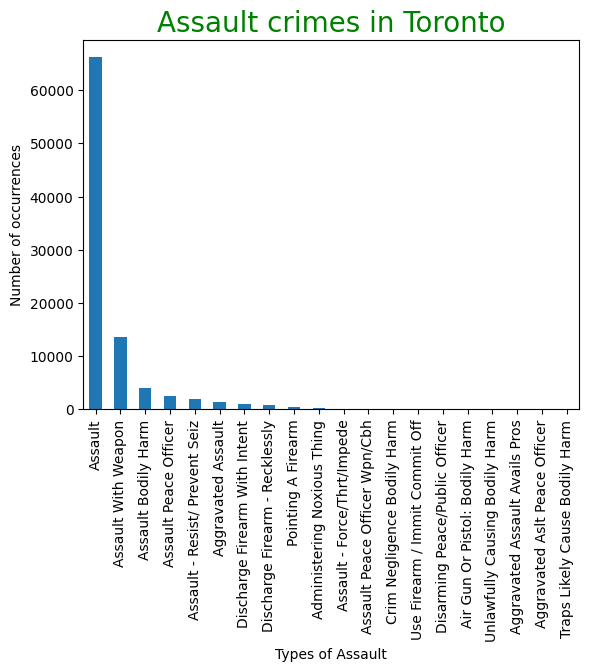

In [ ]:
assault = df[df['MCI'] == 'Assault']
assault_types = assault.groupby('offence', as_index=False).size()
assault_types = assault_types.sort_values(by='size', ascending=False)  # Fix: Add 'by' argument
ax = assault_types.plot.bar(x='offence', y='size', legend=False)  # Explicitly set x and y
ax.set_xlabel('Types of Assault')
ax.set_ylabel('Number of occurrences')
ax.set_title('Assault crimes in Toronto', color='green', fontsize=20)
plt.show()


In [ ]:
df_grouped = df_dropped.groupby(df_dropped['occurrenceyear'])

In [ ]:
#Analysis by year
df_2015 = df_grouped.get_group(2015)
df_2016 = df_grouped.get_group(2016)
df_2017 = df_grouped.get_group(2017)

In [ ]:
df_2015_grouped = df_2015.groupby(df_2015['MCI']).count()
df_2016_grouped = df_2016.groupby(df_2016['MCI']).count()
df_2017_grouped = df_2017.groupby(df_2017['MCI']).count()

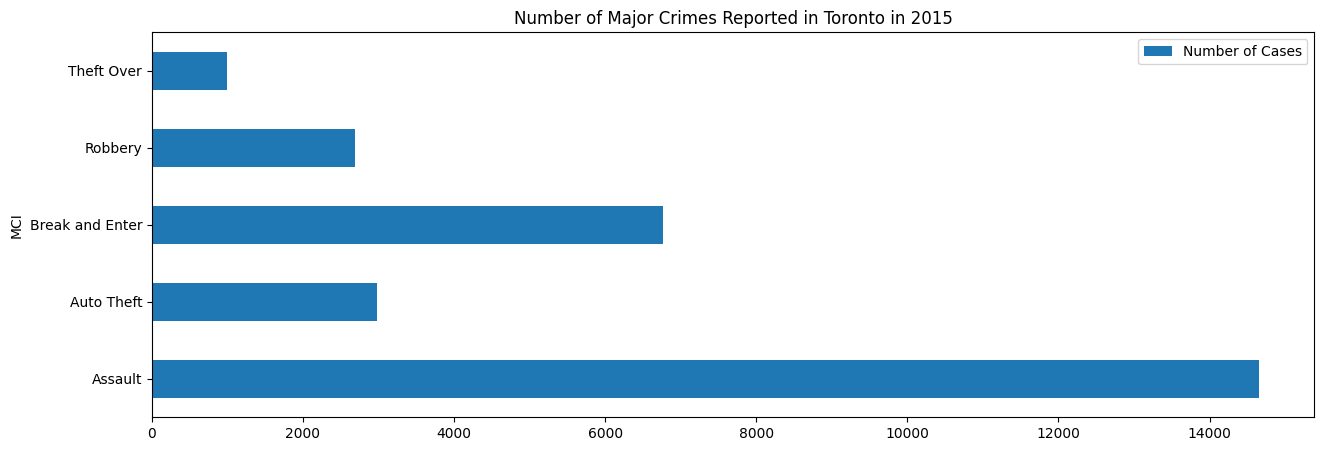

In [ ]:
plot = df_2015_grouped.iloc[:,0]
plot = pd.DataFrame(plot)
plot.columns = ['Number of Cases']
ax = plot.plot(kind='barh',figsize=(15,5),title='Number of Major Crimes Reported in Toronto in 2015')

In [ ]:
df.head()

,X,Y,Index_,event_unique_id,occurrencedate,reporteddate,premisetype,ucr_code,ucr_ext,offence,...,occurrencedayofweek,occurrencehour,MCI,Division,Hood_ID,Neighbourhood,Long,Lat,ObjectId,Total
0,-79.405228,43.656982,7801,GO-20152165447,2015-12-18T03:58:00.000Z,2015-12-18T03:59:00.000Z,Commercial,1430,100,Assault,...,Friday,3,Assault,D14,79,University (79),-79.405228,43.656982,7001,1
1,-79.307907,43.778732,7802,GO-20151417245,2015-08-15T21:45:00.000Z,2015-08-17T22:11:00.000Z,Commercial,1430,100,Assault,...,Saturday,21,Assault,D42,118,Tam O'Shanter-Sullivan (118),-79.307907,43.778732,7002,1
2,-79.225029,43.765942,7803,GO-20151421107,2015-08-16T16:00:00.000Z,2015-08-18T14:40:00.000Z,Apartment,2120,200,B&E,...,Sunday,16,Break and Enter,D43,137,Woburn (137),-79.225029,43.765942,7003,1
3,-79.140823,43.778648,7804,GO-20152167714,2015-11-26T13:00:00.000Z,2015-12-18T13:38:00.000Z,Other,2120,200,B&E,...,Thursday,13,Break and Enter,D43,133,Centennial Scarborough (133),-79.140823,43.778648,7004,1
4,-79.288361,43.691235,7805,GO-20152169954,2015-12-18T19:50:00.000Z,2015-12-18T19:55:00.000Z,Commercial,1430,100,Assault,...,Friday,19,Assault,D55,61,Taylor-Massey (61),-79.288361,43.691235,7005,1


In [ ]:

col_list = ['occurrenceyear',	'occurrencemonth','occurrenceday','occurrencedayofyear','occurrencedayofweek','occurrencehour','MCI',	'Division',	'Hood_ID','premisetype']


df2 = df[col_list]
df2 = df2[df2['occurrenceyear'] > 2013]

#Factorize dependent variable column:
crime_var = pd.factorize(df2['MCI'])
df2['MCI'] = crime_var[0]
definition_list_MCI = crime_var[1]

#factorize independent variables:
premise_var = pd.factorize(df2['premisetype'])
df2['premisetype'] = premise_var[0]
definition_list_premise = premise_var[1]

#factorize occurenceyear:
year_var = pd.factorize(df2['occurrenceyear'])
df2['occurrenceyear'] = year_var[0]
definition_list_year = year_var[1]

#factorize occurencemonth:
month_var = pd.factorize(df2['occurrencemonth'])
df2['occurrencemonth'] = month_var[0]
definition_list_month = month_var[1]

#factorize occurenceday:
day_var = pd.factorize(df2['occurrenceday'])
df2['occurenceday'] = day_var[0]
definition_list_day = day_var[1]

#factorize occurencedayofweek:
dayweek_var = pd.factorize(df2['occurrencedayofweek'])
df2['occurrencedayofweek'] = dayweek_var[0]
definition_list_day = dayweek_var[1]

#factorize division:
division_var = pd.factorize(df2['Division'])
df2['Division'] = division_var[0]
definition_list_division = division_var[1]

#factorize HOOD_ID:
hood_var = pd.factorize(df2['Hood_ID'])
df2['Hood_ID'] = hood_var[0]
definition_list_hood = hood_var[1]

#factorize occurencehour:
hour_var = pd.factorize(df2['occurrencehour'])
df2['occurrencehour'] = hour_var[0]
definition_list_hour = hour_var[1]

#factorize occurencedayofyear:
dayyear_var = pd.factorize(df2['occurrencedayofyear'])
df2['occurrencedayofyear'] = dayyear_var[0]
definition_list_dayyear = dayyear_var[1]

In [ ]:
df2.head()

,occurrenceyear,occurrencemonth,occurrenceday,occurrencedayofyear,occurrencedayofweek,occurrencehour,MCI,Division,Hood_ID,premisetype,occurenceday
0,0,0,18.0,0,0,0,0,0,0,0,0
1,0,1,15.0,1,1,1,0,1,1,0,1
2,0,1,16.0,2,2,2,1,2,2,1,2
3,0,2,26.0,3,3,3,1,2,3,2,3
4,0,0,18.0,0,0,4,0,3,4,0,0


In [ ]:
binary_encoder = OneHotEncoder(sparse_output=False)  # Updated: 'sparse_output' replaces 'sparse'
encoded_X = binary_encoder.fit_transform(x)
X_train_OH, X_test_OH, y_train_OH, y_test_OH = train_test_split(encoded_X, y, test_size=0.25, random_state=21)

classifier = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print("Accuracy of Random Forest:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=definition_list_MCI))


Accuracy of Random Forest: 0.5838382934955169
[[18818  2625   427    67  1007]
 [ 4921  5511    51    20   213]
 [ 3109   371   338    11   398]
 [ 1101   355    34    22   134]
 [ 2785   761   207    15  1422]]
                 precision    recall  f1-score   support

        Assault       0.61      0.82      0.70     22944
Break and Enter       0.57      0.51      0.54     10716
        Robbery       0.32      0.08      0.13      4227
     Theft Over       0.16      0.01      0.02      1646
     Auto Theft       0.45      0.27      0.34      5190

       accuracy                           0.58     44723
      macro avg       0.42      0.34      0.35     44723
   weighted avg       0.54      0.58      0.54     44723



In [ ]:
classifier = RandomForestClassifier(n_estimators = 100, criterion = 'entropy', random_state = 42)
classifier.fit(X_train_OH, y_train_OH)
y_pred_OH = classifier.predict(X_test_OH)

print("Accuracy of Random Forest with OneHotEncoder : ",accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test_OH, y_pred_OH))
print(classification_report(y_test_OH,y_pred_OH, target_names=definition_list_MCI))

NameError: name 'X_train_OH' is not defined

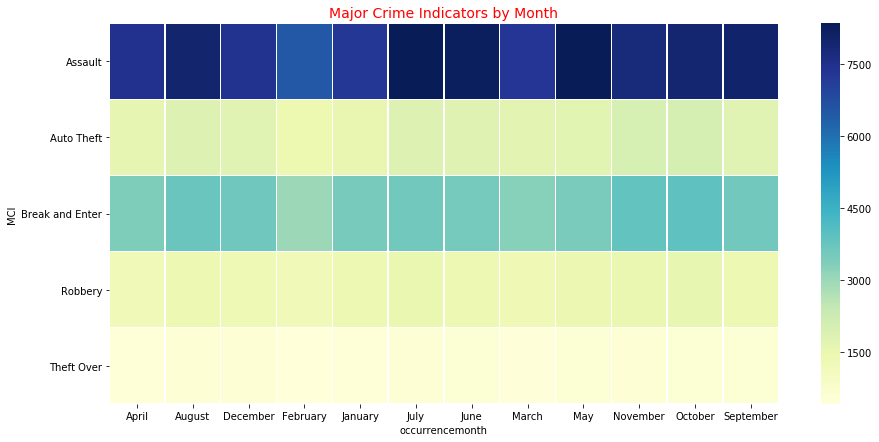

In [ ]:
import seaborn as sns
mci_monthwise = df.groupby(['occurrencemonth','MCI'],as_index=False).agg({'Total':'sum'})

plt.figure(figsize=(15, 7))
crime_count = mci_monthwise.pivot("MCI","occurrencemonth","Total" )

plt.yticks(rotation=1)
ax = sns.heatmap(crime_count,cmap="YlGnBu", linewidths=.5)
plt.title("Major Crime Indicators by Month",color = 'red',fontsize=14)
plt.show()


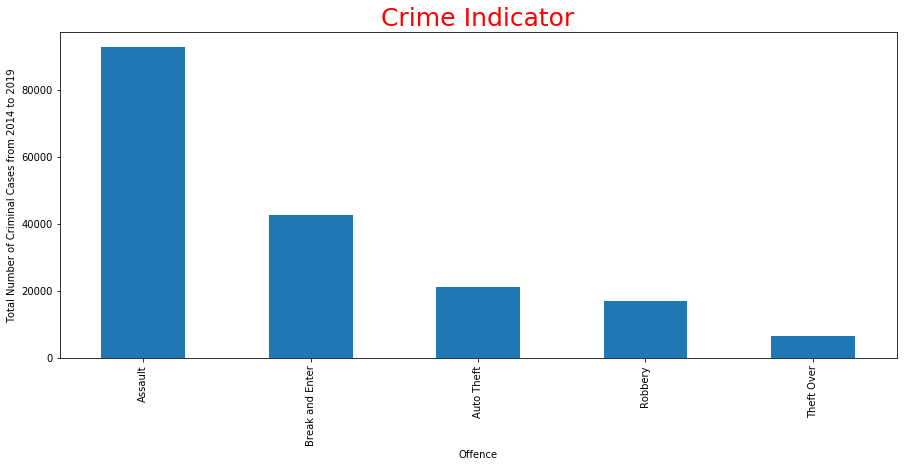

In [ ]:
major_crime_indicator = df.groupby('MCI',as_index=False).size()
plt.subplots(figsize = (15, 6))
ct = major_crime_indicator.sort_values(ascending = False)
ax = ct.plot.bar()
ax.set_xlabel('Offence')
ax.set_ylabel('Total Number of Criminal Cases from 2014 to 2019')
ax.set_title('Crime Indicator',color = 'red',fontsize=25)
plt.show()

Text(0.5, 1.0, 'Crime Types by Hour of Day in Toronto')

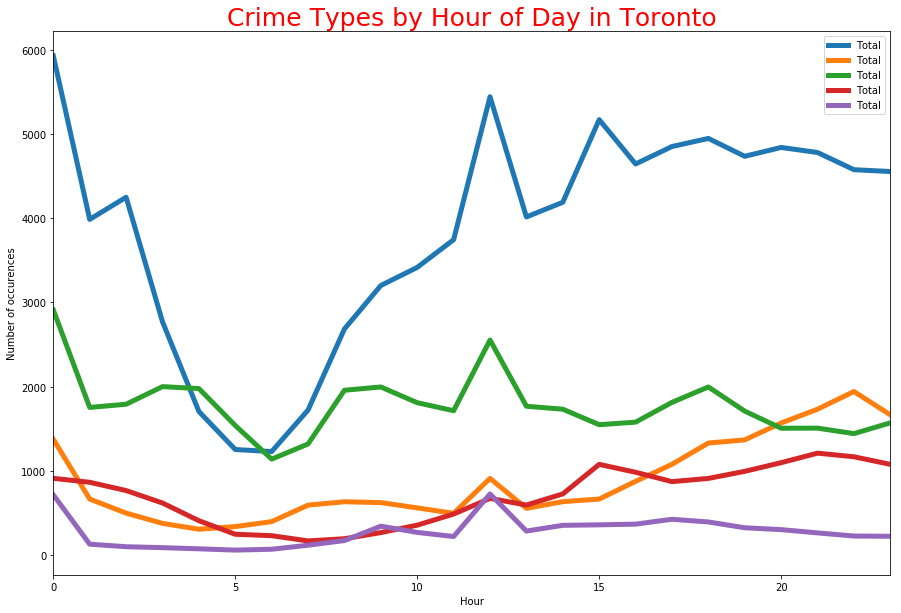

In [ ]:
hour_crime_group = df.groupby(['occurrencehour','MCI'],as_index=False).agg({'Total':'sum'})
fig, ax = plt.subplots(figsize=(15,10))
hour_crime_group.groupby('MCI').plot(x="occurrencehour", y="Total", ax=ax,linewidth=5)
ax.set_xlabel('Hour')
ax.set_ylabel('Number of occurences')
ax.set_title('Crime Types by Hour of Day in Toronto',color = 'red',fontsize=25)

In [ ]:
df_g0 = df_2015.groupby(['Neighbourhood','MCI']).size().to_frame('count').reset_index()
df_g0 = df_g0.pivot(index='Neighbourhood',columns='MCI',values='count')
df_g0 = df_g0.dropna()

df_g = df_2016.groupby(['Neighbourhood','MCI']).size().to_frame('count').reset_index()
df_g = df_g.pivot(index='Neighbourhood',columns='MCI',values='count')
df_g = df_g.dropna()


df_g2 = df_2017.groupby(['Neighbourhood','MCI']).size().to_frame('count').reset_index()
df_g2 = df_g2.pivot(index='Neighbourhood',columns='MCI',values='count')
df_g2 = df_g2.dropna()

In [ ]:
df_g0.head(10)

MCI,Assault,Auto Theft,Break and Enter,Robbery,Theft Over
Neighbourhood,,,,,
Agincourt North (129),57.0,26.0,51.0,29.0,5.0
Agincourt South-Malvern West (128),88.0,26.0,59.0,15.0,11.0
Alderwood (20),37.0,15.0,26.0,6.0,4.0
Annex (95),168.0,14.0,103.0,28.0,18.0
Banbury-Don Mills (42),67.0,18.0,87.0,12.0,15.0
Bathurst Manor (34),31.0,22.0,29.0,7.0,2.0
Bay Street Corridor (76),570.0,21.0,161.0,76.0,37.0
Bayview Village (52),85.0,14.0,35.0,4.0,8.0
Bayview Woods-Steeles (49),37.0,7.0,34.0,2.0,1.0


In [ ]:
scaler = StandardScaler()
Sum_of_squared_distances0 = []
Sum_of_squared_distances = []
Sum_of_squared_distances2 = []

std_scale = scaler.fit(df_g0)
df_transformed0 = std_scale.transform(df_g0)
pca = PCA(n_components=3)
pca = pca.fit(df_transformed0)
X0 = pca.transform(df_transformed0)
K = range(1,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(df_transformed0)
    Sum_of_squared_distances0.append(km.inertia_)


std_scale = scaler.fit(df_g)
df_transformed = std_scale.transform(df_g)
pca = PCA(n_components=3)
pca = pca.fit(df_transformed)
X = pca.transform(df_transformed)
K = range(1,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(df_transformed)
    Sum_of_squared_distances.append(km.inertia_)


std_scale = scaler.fit(df_g2)
df_transformed2 = std_scale.transform(df_g2)
pca = PCA(n_components=3)
pca = pca.fit(df_transformed2)
X1 = pca.transform(df_transformed2)

K = range(1,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(df_transformed2)
    Sum_of_squared_distances2.append(km.inertia_)


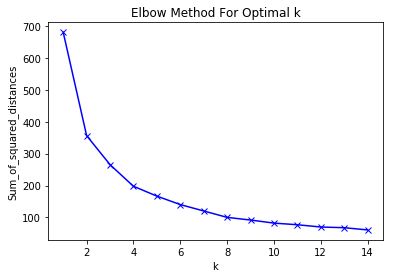

In [ ]:
plt.plot(K, Sum_of_squared_distances0, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

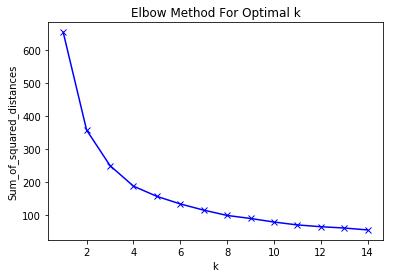

In [ ]:
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

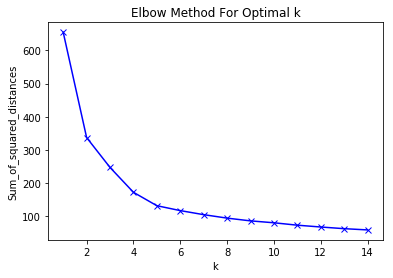

In [ ]:
plt.plot(K, Sum_of_squared_distances2, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

For n_clusters = 2 The average silhouette_score is : 0.7307306081429717
For n_clusters = 3 The average silhouette_score is : 0.4511660188781014
For n_clusters = 4 The average silhouette_score is : 0.4529368049556418
For n_clusters = 5 The average silhouette_score is : 0.4776823069308707


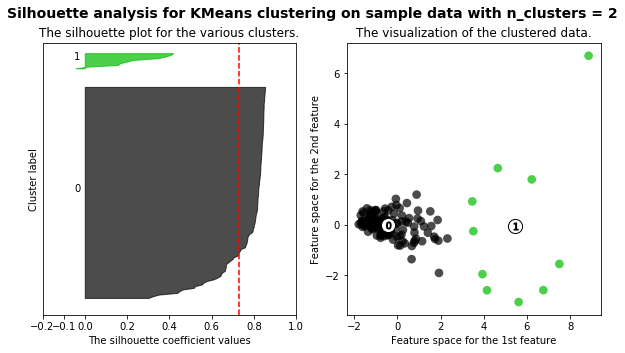

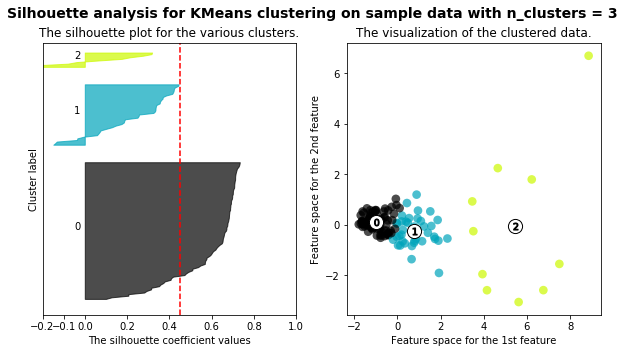

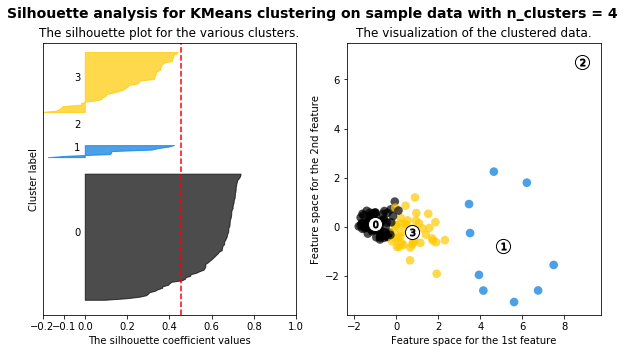

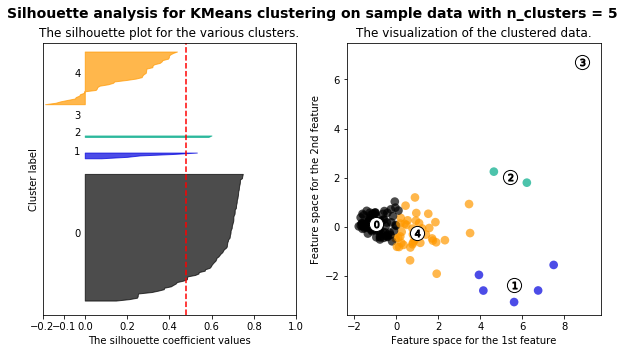

No handles with labels found to put in legend.
No handles with labels found to put in legend.


In [ ]:
for n_clusters in range(2,6):
    kmeans = KMeans(n_clusters=n_clusters , random_state=3425)
    cluster_labels = kmeans.fit_predict(X0)
    silhouette_avg = silhouette_score(X0, cluster_labels)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)
    sample_silhouette_values = silhouette_samples(X0, cluster_labels)

    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(10, 5)


    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])


    y_lower = 10
    for i in range(n_clusters):
       # samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Computing the new y_lower
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # vertical line
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])
    ax1.set_xticks([-0.2,-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # showing the actual cluster
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X0[:, 0], X0[:, 1], marker='.', s=300, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = kmeans.cluster_centers_
    #  cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),fontsize=14, fontweight='bold')

plt.show()
ax1.legend()
ax2.legend()

In [ ]:
#Plotting the cluster obtained using GMM
kmeans = KMeans(n_clusters=2,random_state=3425)
colors = ['green','blue']


plt.figure(figsize=(15, 5))

ax = plt.subplot(121)
kc =kmeans.fit(df_transformed0)
label = pd.DataFrame(kc.labels_)
df_result =pd.DataFrame(df_transformed0)
# label = label.sort_values(by=0)
df_result['label']=label

scatter = plt.scatter(df_result[0],df_result[2],
                     c=list(label.iloc[:,0]), cmap=matplotlib.colors.ListedColormap(colors),s=50)
plt.title('K-Means Clustering Without PCA')
plt.xlabel('Assault')
plt.ylabel('Auto-Theft')
plt.colorbar(scatter)


ax = plt.subplot(122)
start = timeit.default_timer()
kc =kmeans.fit(X0)
stop = timeit.default_timer()
klabel0 = pd.DataFrame(kc.labels_)
df_result =pd.DataFrame(X0)
# klabel0 = klabel0.sort_values(by=0)
df_result['label']=klabel0
scatter = plt.scatter(df_result[0],df_result[2],
                      c = list(klabel0.iloc[:,0]), cmap=matplotlib.colors.ListedColormap(colors),s=50)
plt.title('K-Means Clustering With PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter)
print("running time is :",stop-start)
plt.show()


colors = ['green','blue']
#Plotting the cluster obtained using GMM
kmeans = KMeans(n_clusters=2,random_state=342)
plt.figure(figsize=(15, 10))

ax = plt.subplot(221)

kc =kmeans.fit(df_transformed)

label = pd.DataFrame(kc.labels_)
df_result =pd.DataFrame(df_transformed)
label.sort_values(by=0)
df_result['label']=label
scatter = plt.scatter(df_result[0],df_result[2],
                       c = list(label.iloc[:,0]), cmap= matplotlib.colors.ListedColormap(colors),s=50)
plt.title('K-Means Clustering Without PCA :')
plt.xlabel('Assault')
plt.ylabel('Auto-Theft')
plt.colorbar(scatter)

ax = plt.subplot(222)
start = timeit.default_timer()
kc =kmeans.fit(X)
stop = timeit.default_timer()
klabel1 = pd.DataFrame(kc.labels_)
df_result =pd.DataFrame(X)
klabel1.sort_values(by=0)
df_result['label']=klabel1
scatter = plt.scatter(df_result[0],df_result[2],
                      c = list(klabel1.iloc[:,0]), cmap= matplotlib.colors.ListedColormap(colors),s=50)
plt.title('K-Means Clustering With PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter)
print("running time is :",stop-start)
plt.show()


#Plotting the cluster obtained using GMM
kmeans = KMeans(n_clusters=2,random_state=342)
plt.figure(figsize=(15, 15))
ax = plt.subplot(321)
kc =kmeans.fit(df_transformed2)
label = pd.DataFrame(kc.labels_)
df_result =pd.DataFrame(df_transformed2)
label.sort_values(by=0)
df_result['label']=label
scatter = plt.scatter(df_result[0],df_result[2],
                      c = list(label.iloc[:,0]), cmap= matplotlib.colors.ListedColormap(colors),s=50)
plt.title('K-Means Clustering Without PCA')
plt.xlabel('Assault')
plt.ylabel('Auto-Theft')
plt.colorbar(scatter)
ax.legend()

ax = plt.subplot(322)
start = timeit.default_timer()
kc =kmeans.fit(X1)
stop = timeit.default_timer()
klabel2 = pd.DataFrame(kc.labels_)
df_result =pd.DataFrame(X1)
klabel2.sort_values(by=0)
df_result['label']=klabel2
scatter = plt.scatter(df_result[0],df_result[2],
                      c = list(klabel2.iloc[:,0]), cmap= matplotlib.colors.ListedColormap(colors),s=50)
plt.title('K-Means Clustering With PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter)
print("running time is :",stop-start)
ax.legend()
plt.show()
ax.legend()

In [ ]:
X_list = [X0, X, X1]
year_list = [2015,2016,2017]
for i,y in zip(X_list,year_list):
    from sklearn import metrics
    clustering = KMeans(n_clusters=2,random_state=3425).fit(i)
    labels = clustering.labels_
    print("Silhouette score(K-means) for year",y,"is",metrics.silhouette_score(i, labels, metric='euclidean'))

In [ ]:
neighborhoods0 = df_g0.index
neighborhoods0 = np.array(neighborhoods0)

neighborhoods = df_g.index
neighborhoods = np.array(neighborhoods)

neighborhoods2 = df_g2.index
neighborhoods2 = np.array(neighborhoods2)
#Display Neighboorhoods
print('Crime Neighborhoods by K-Means in 2015')
print(neighborhoods0[np.where(klabel0[0]==1)])
kviolent15 = neighborhoods0[np.where(klabel0[0]==1)]
kviolent15s = neighborhoods0[np.where(klabel0[0]==0)]
kviolent15m = neighborhoods0[np.where(klabel0[0]==2)]

print('Crime Neighborhoods by K-Means in 2016')
print(neighborhoods[np.where(klabel1[0]==1)])
kviolent16 = neighborhoods[np.where(klabel1[0]==1)]
kviolent16s = neighborhoods[np.where(klabel1[0]==0)]
kviolent16m = neighborhoods[np.where(klabel1[0]==2)]


print('Crime Neighborhoods by K-Means in 2017')
print(neighborhoods2[np.where(klabel2[0]==1)])
kviolent17 = neighborhoods2[np.where(klabel2[0]==1)]
kviolent17s = neighborhoods2[np.where(klabel2[0]==0)]
kviolent17m = neighborhoods2[np.where(klabel2[0]==2)]

In [ ]:
plt.figure(num=None, figsize=(10, 8))
plt.scatter("Long", "Lat", data = df, c = 'y',alpha = 0.1, edgecolor = 'black', s=2)
plt.grid()
plt.xlabel('long')
plt.ylabel('lat')
plt.title('Toronto Crime')
plt.tight_layout()
plt.axis('tight')

plt.show()

### SECTION2


plt.figure(num=None, figsize=(10, 8)) plt.scatter("Long", "Lat", data = df, c = 'y',alpha = 0.1, edgecolor = 'black', s=2) plt.grid() plt.xlabel('long') plt.ylabel('lat') plt.title('Toronto Crime') plt.tight_layout() plt.axis('tight')

plt.show()

In [ ]:
pip install selenium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.0/476.0 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.0 MB/s eta 0:00:00


In [ ]:
pip install Autoscraper

In [ ]:
from autoscraper import AutoScraper

url = 'https://github.com/alirezamika/autoscraper'

wanted_list = ['A Smart, Automatic, Fast and Lightweight Web Scraper for Python', '6.2k', 'https://github.com/alirezamika/autoscraper/issues']

scraper = AutoScraper()
scraper.build(url, wanted_list)

['A Smart, Automatic, Fast and Lightweight Web Scraper for Python',
 '6.2k',
 '123',
 '651',
 'https://github.com/alirezamika/autoscraper',
 'https://github.com/alirezamika/autoscraper/issues',
 'https://github.com/alirezamika/autoscraper/pulls',
 'https://github.com/alirezamika/autoscraper/discussions',
 'https://github.com/alirezamika/autoscraper/actions',
 'https://github.com/alirezamika/autoscraper/projects',
 'https://github.com/alirezamika/autoscraper/wiki',
 'https://github.com/alirezamika/autoscraper/security',
 'https://github.com/alirezamika/autoscraper/pulse']

In [ ]:
from autoscraper import AutoScraper

url = 'https://timesofindia.indiatimes.com/sports/cricket/'

# We can add one or multiple candidates here.
# You can also put urls here to retrieve urls.
wanted_list = ['wickets','overs','odi','test','ipl']

scraper = AutoScraper()
result = scraper.build(url, wanted_list)
print(result)

[]


In [ ]:
pip install webdriver-manager

In [ ]:
!pip install -q webdriver_manager

In [ ]:
from selenium import webdriver
from selenium.webdriver.safari.service import Service
#from webdriver_manager import SafariDriverManager
from autoscraper import AutoScraper
import time


In [ ]:

# Initialize the Chrome WebDriver using Selenium
def get_webdriver():
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")  # Run in headless mode for better performance
    driver = webdriver.Chrome(service=Service(SafariDriverManager().install()), options=options)
    return driver

# Load the webpage and get the rendered HTML
def load_page(driver, url):
    driver.get(url)
    time.sleep(3)  # Wait for the page to fully load (adjust as needed for dynamic content)
    return driver.page_source

# Close the WebDriver session
def close_driver(driver):
    driver.quit()

# Scrape the loaded page with AutoScraper
def scrape_with_autoscraper(html_content, wanted_list):
    scraper = AutoScraper()
    scraper.build(url, wanted_list, html=html_content)
    return scraper.get_result_similar(url, html=html_content)

# Example function to scrape TOI's crime section
def scrape_toi_crime_news():
    url = 'https://timesofindia.indiatimes.com/topic/Crime'

    # Use Selenium to get the fully rendered page
    driver = get_webdriver()
    html_content = load_page(driver, url)

    # Define the wanted list (example headline and URL you want to scrape)
    wanted_list = ["Delhi: Three arrested for duping elderly woman of Rs 6 lakh",  # Example headline
                   "https://timesofindia.indiatimes.com/city/delhi/delhi-three-arrested-for-duping-elderly-woman-of-rs-6-lakh/articleshow/101518133.cms"]  # Example link

    # Use AutoScraper to scrape the dynamic content from the rendered HTML
    result = scrape_with_autoscraper(html_content, wanted_list)

    # Close the Selenium driver session
    close_driver(driver)

    # Print the result
    for item in result:
        print(item)

# Run the scraping
scrape_toi_crime_news()

NameError: name 'SafariDriverManager' is not defined

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
from autoscraper import AutoScraper
import time

def setup_driver():
    chrome_options = Options()
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)
    return driver

def scrape_toi_crime_news():
    url = 'https://timesofindia.indiatimes.com/topic/Crime'

    driver = setup_driver()

    driver.get(url)
    time.sleep(3)

    html_content = driver.page_source

    # Define wanted list for AutoScraper
    wanted_list = ["Delhi: Three arrested for duping elderly woman of Rs 6 lakh",
                   "https://timesofindia.indiatimes.com/city/delhi/delhi-three-arrested-for-duping-elderly-woman-of-rs-6-lakh/articleshow/101518133.cms"]  # Example link

    # Create AutoScraper instance
    scraper = AutoScraper()
    scraper.build(url, wanted_list)

    # Get results using AutoScraper
    results = scraper.get_result_similar(url, grouped=True)

    # Close the Selenium driver
    driver.quit()

    # Print results
    for key, value in results.items():
        print(f"{key}: {value}")

# Run the scraping function
scrape_toi_crime_news()

WebDriverException: Message: unknown error: cannot find Chrome binary
Stacktrace:
#0 0x5c21e9d7b4e3 <unknown>
#1 0x5c21e9aaac76 <unknown>
#2 0x5c21e9ad1757 <unknown>
#3 0x5c21e9ad0029 <unknown>
#4 0x5c21e9b0eccc <unknown>
#5 0x5c21e9b0e47f <unknown>
#6 0x5c21e9b05de3 <unknown>
#7 0x5c21e9adb2dd <unknown>
#8 0x5c21e9adc34e <unknown>
#9 0x5c21e9d3b3e4 <unknown>
#10 0x5c21e9d3f3d7 <unknown>
#11 0x5c21e9d49b20 <unknown>
#12 0x5c21e9d40023 <unknown>
#13 0x5c21e9d0e1aa <unknown>
#14 0x5c21e9d646b8 <unknown>
#15 0x5c21e9d64847 <unknown>
#16 0x5c21e9d74243 <unknown>
#17 0x7c4f39f08ac3 <unknown>


In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import time

# Initialize Safari driver
driver = webdriver.Safari()

try:
    # Navigate to the URL
    url = "https://timesofindia.indiatimes.com/article/101518133.cms"
    driver.get(url)

    # Wait for the page to load completely
    time.sleep(5)  # Adjust time as necessary

    # Extract data (example: title and content)
    title = driver.find_element(By.TAG_NAME, 'h1').text
    content = driver.find_element(By.CLASS_NAME, 'article').text  # Adjust class name based on the page structure

    # Print extracted data
    print("Title:", title)
    print("Content:", content)

finally:
    # Close the driver
    driver.quit()


NoSuchDriverException: Message: Unable to obtain driver for safari; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors/driver_location
